In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import pandas as pd
import torch
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from torchvision import transforms, utils
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn                  
import torch.nn.functional as F         
import machine_learning
from sklearn.metrics import confusion_matrix
import seaborn as sns
import re 
import shap 
from sklearn.metrics import balanced_accuracy_score
import pickle
from scipy.ndimage import label
import cartopy.crs as ccrs
import os
import matplotlib.colors as mcolors
import shutil
from PIL import Image

from machine_learning import convnext_functions
from machine_learning import SPEI_extremes_location_dataset


In [2]:
site = 'cordoba'

# -----------------------------------------

# ========================================
# Dataset configurations
# ========================================

variables_era5 = ['g500','g200','psl']
variables_era5land = ['swvl1', 'swvl2', 'swvl3']

# ========================================
# Percentile and SPEI
percentile = '90p'
using_spei  = False  # True if using SPEI as additional feature, False if not
# ========================================


start_date = "1950-01-01"

_ERA5LAND_TRAIN_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2013-12-31",
    months = [6,7,8],
    variables = variables_era5land,
    extreme_variable = 'tasmax_extreme_classification',
    model_data = False
        )

_ERA5LAND_TEST_DATASET_CONF = dict(
    start_date= "2014-01-01",
    end_date= "2023-12-31",
    months = [6,7,8],
    variables = variables_era5land,
    extreme_variable = 'tasmax_extreme_classification',
    model_data = False
    )

_ERA5_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5,
model_data = False
    )

_ERA5_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5,
model_data = False     
    )

number_lags = _ERA5_TRAIN_DATASET_CONF['lags_era5']

# =========================================
# Dataloaders 
# =========================================

_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
    )


_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
    )
    
    
HYPMS = dict(
    epochs= 75,
    lr= 1e-4,
    w_decay= 0.01,
)

# Start date for all datasets
start_date = "1950-01-01"
# Variables large-scale and local scale to use 
variables_era5 = ['g500','g200','psl'] 
variables_era5land = ['swvl1','swvl2','swvl3']  

# Local-scale datasets configuration
_ERA5LAND_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
variables = variables_era5land
    )

_ERA5LAND_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
variables = variables_era5land
    )

# Large-scale datasets configuration
_ERA5_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5
    )

_ERA5_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5      
    )

percentile_to_load = '90p'

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

#File paths ERA5 data 

file_g500 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/psl_1x1_lagged_standarized_anomalies.nc"

# File local scale
file_local_scale = f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile_to_load}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc"
    

# Train features 

train_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=file_local_scale, file_CO2=file_CO2 , **_ERA5LAND_TRAIN_DATASET_CONF)
test_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=file_local_scale, file_CO2=file_CO2 , **_ERA5LAND_TEST_DATASET_CONF)
    

number_lags = 3

train_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TRAIN_DATASET_CONF) # shape: features, time, lat, lon 
test_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TEST_DATASET_CONF)
    

# Combined Dataset and Dataloader 

batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets

combined_train_dataset  = machine_learning.CombinedDataset(train_dataset,train_features_era5, variables=variables_era5)
combined_test_dataset = machine_learning.CombinedDataset(test_dataset,test_features_era5, variables=variables_era5)
    


train_size_combined = int(0.8 * len(combined_train_dataset))
val_size_combined = len(combined_train_dataset) - train_size_combined

#random split 
train_subset_combined, val_subset_combined = random_split(combined_train_dataset, [train_size_combined, val_size_combined])

# (local,regional,labels)
combined_train_loader = DataLoader(train_subset_combined, **_DATALOADERS_CONF) # When using DataLoader with shuffle=True, PyTorch randomly picks idx values.
combined_val_loader = DataLoader(val_subset_combined, **_DATALOADERS_CONF)
combined_test_loader = DataLoader(combined_test_dataset, **_DATALOADERS_TEST_CONF)



batch_size = _DATALOADERS_TEST_CONF['batch_size'] # batch size for dataloaders both datasets
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Explainer data for SHAP 

explainer_indices = np.arange(0,len(combined_test_dataset),1)

explain_nn = []
explain_cnn = []

for idx in explainer_indices:
    nn_input, cnn_input, labels = combined_test_dataset[idx]  # Adjust based on your dataset structure
    explain_nn.append(nn_input)
    explain_cnn.append(cnn_input)

explain_nn = torch.stack(explain_nn,dim=0).to(device)
explain_cnn = torch.stack(explain_cnn,dim=0).to(device)

explain_data = [explain_nn, explain_cnn]


# Load computed SHAP

main_path = '/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/'
with open(os.path.join(main_path, f'nolags_90p_SHAP_results_{site}.pkl'), 'rb') as f:
    loaded_shap_dict = pickle.load(f)


#with open(f'SHAP_values_Gradient/def_ensamble/SHAP_values_GradientExplainer_not_filtered_{site}_{number_lags}lags.pkl', 'rb') as f:
#        loaded_shap_dict = pickle.load(f)

TypeError: CombinedDataset.__init__() got an unexpected keyword argument 'variables'

# Summer HW july 2024 Cordoba

In [3]:

start_date='2014-01-01'
end_date='2024-12-31'
months=[6,7,8]
ds_g500 = xr.open_dataset(file_g500).sel(time=slice(start_date, end_date))
ds_g500 = ds_g500.sel(time=ds_g500.time.dt.month.isin(months), drop=True)

dates = ds_g500['time'].values

# dates té un dia por ai de juliol que no està inclós perquè faltava en les dades de esarchive 

target_dates = np.array([f"2021-08-{i}T11:30:00" for i in range(10,17)],dtype='datetime64[ns]')

indices = np.where(np.isin(dates, target_dates))[0]

#main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
#with open(os.path.join(main_path, f'results_data_{site}.pkl'), 'rb') as f:
#    dict_results = pickle.load(f)

main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
with open(os.path.join(main_path, f'nolags_90p_results_data_{site}.pkl'), 'rb') as f:
    dict_results = pickle.load(f)

out_probabilities = dict_results['out_probs_sites']   
std_probs = dict_results['std_probs_sites'] 

y_true,y_pred = dict_results['y_true_pred_pairs']
y_true = np.array(y_true)
y_pred = np.array(y_pred)

shap_values_nn_raw = loaded_shap_dict['nn_mean']
shap_values_cnn_raw = loaded_shap_dict['cnn_mean']


shap_std_nn_raw = loaded_shap_dict['nn_std']
shap_std_cnn_raw = loaded_shap_dict['cnn_std']

threshold_nn_low = np.percentile(shap_std_nn_raw,5,axis=0)
threshold_nn_up = np.percentile(shap_std_nn_raw,95,axis=0)

threshold_cnn_low = np.percentile(shap_std_cnn_raw,2.,axis=0)
threshold_cnn_up = np.percentile(shap_std_cnn_raw,98.,axis=0)

# Create masks: True if the SHAP value is statistically significant
significance_mask_nn = (np.abs(shap_values_nn_raw) > threshold_nn_low)&(np.abs(shap_values_nn_raw) < threshold_nn_up)
significance_mask_cnn = (np.abs(shap_values_cnn_raw) > threshold_cnn_low)&(np.abs(shap_values_cnn_raw) < threshold_cnn_up)

# Filtes for study case with indices 
shap_values_nn_study_case = shap_values_nn_raw[indices,:]
shap_values_cnn_study_case = shap_values_cnn_raw[indices,:,:,:]

significance_mask_nn_study_case = significance_mask_nn[indices,:]
significance_mask_cnn_study_case = significance_mask_cnn[indices,:,:,:]

In [4]:
def create_significance_mask(shap_values, shap_std, z_crit):
    """
    Creates a boolean mask indicating statistically significant SHAP values.

    Args:
        shap_values (np.ndarray): Array of SHAP values (mean).
        shap_std (np.ndarray): Array of SHAP value standard deviations.
        z_crit (float): The critical Z-value for the desired confidence level.

    Returns:
        np.ndarray: A boolean array of the same shape as inputs. 'True'
                    indicates statistical significance.
    """
    # To avoid division by zero, we calculate Z-scores only where std > 0.
    # Where std is 0, the Z-score is set to 0, which will not be significant.
    z_scores = np.divide(shap_values, shap_std,
                        out=np.zeros_like(shap_values, dtype=float),
                        where=shap_std != 0)

    # A value is significant if its absolute Z-score is greater than the
    # critical value. This means its confidence interval does not include zero.
    return np.abs(z_scores) > z_crit


alpha = 0.05

z_critical = norm.ppf(1 - alpha / 2)

# Create the mask for the Neural Network (NN) model
significance_mask_nn = create_significance_mask(shap_values_nn_raw, shap_std_nn_raw, z_critical)

# Create the mask for the Convolutional Neural Network (CNN) model
significance_mask_cnn = create_significance_mask(shap_values_cnn_raw, shap_std_cnn_raw, z_critical)


In [5]:
print(np.array(y_true)[indices])
print(np.array(y_pred)[indices])

[0 1 1 1 1 1 1]
[0 1 1 1 1 1 1]


## Bar plots

/scratch/tmp/31378709/ipykernel_2615566/3469821642.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(expl_nn.values, expl_nn.data, feature_names=expl_nn.feature_names)


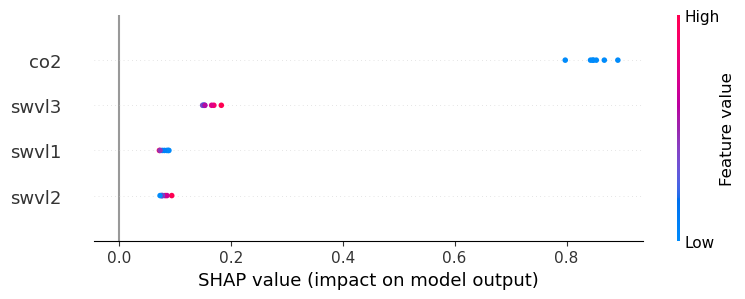

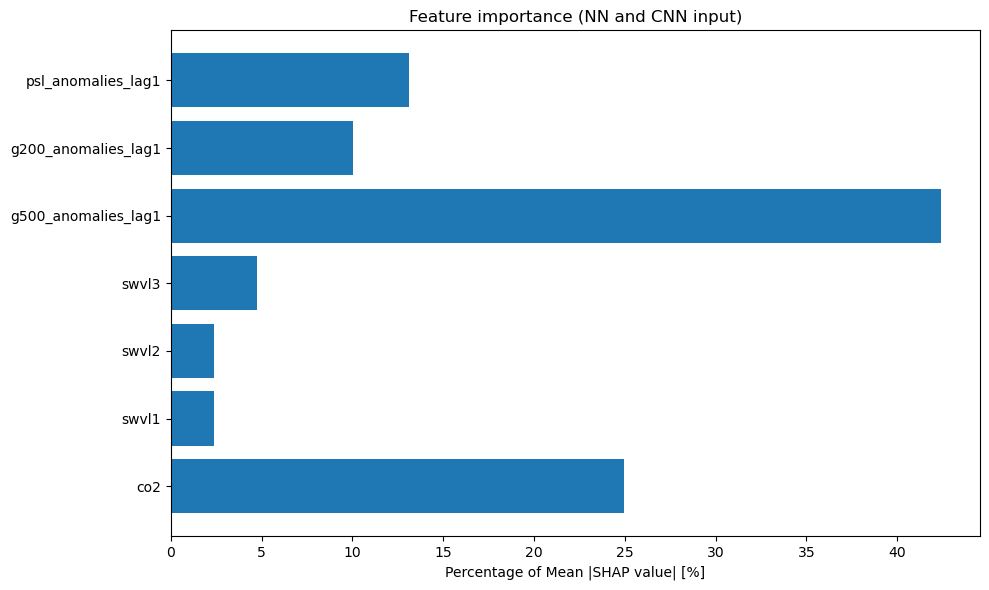

In [6]:

explain_nn_np = explain_nn.cpu().numpy()
explain_nn_np

nn_feature_names = train_dataset.all_features
cnn_feature_names = train_features_era5.all_features
all_names = nn_feature_names + cnn_feature_names

cleaned_names = [
    name.replace(" anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace(" anomalies", "")
    for name in all_names
    ]

# Convert to shap.Explanation object
expl_nn = shap.Explanation(
    values=shap_values_nn_study_case,
    data=explain_nn.cpu().numpy()[indices],  # or .detach().cpu().numpy() if needed
    feature_names=nn_feature_names
)

shap.summary_plot(expl_nn.values, expl_nn.data, feature_names=expl_nn.feature_names)

shap_values_cnn_sum_spatial = np.sum(np.ma.masked_array(shap_values_cnn_study_case,mask=~significance_mask_cnn_study_case),axis=(2,3))


all_shap_values = np.concatenate([np.ma.masked_array(shap_values_nn_study_case,mask=~significance_mask_nn_study_case),shap_values_cnn_sum_spatial],axis=1)
all_shap_values = np.concatenate([shap_values_nn_study_case,shap_values_cnn_sum_spatial],axis=1)


mean_abs_shap = np.mean(np.abs(all_shap_values), axis=0)

total_shap = np.sum(mean_abs_shap)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(cleaned_names, mean_abs_shap / total_shap * 100)  # Top 20 features
plt.xlabel("Percentage of Mean |SHAP value| [%]")
plt.title("Feature importance (NN and CNN input)")
plt.tight_layout()
plt.show()

## Temporal evolution SHAP

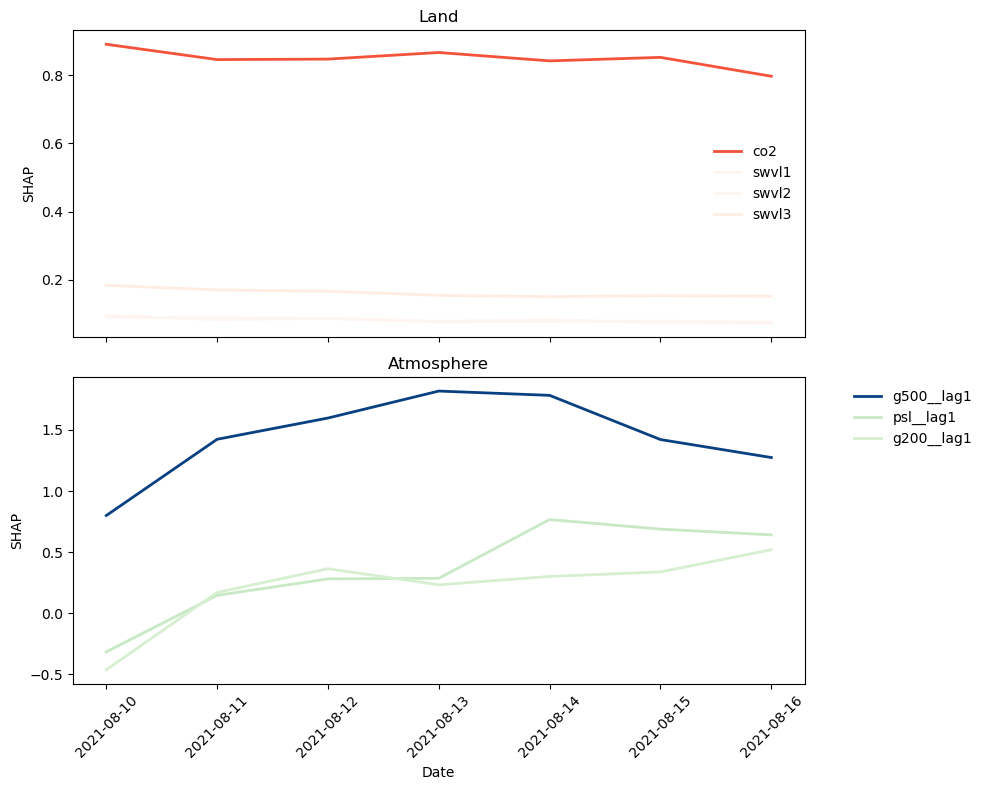

In [7]:

from matplotlib.colors import Normalize


all_shap_values.shape

shap_atmosphere = all_shap_values[4:]

target_dates_d = target_dates.astype('datetime64[D]')
target_dates_plot = target_dates_d.astype('O') 

cleaned_names = [name.replace("lagged_", "").replace("era5", "").replace("anomalies", "") for name in all_names]

mean_abs_shap = np.abs(all_shap_values).mean(axis=0)

# Normalize the importance values to [0, 1] for colormap
norm = Normalize(vmin=mean_abs_shap.min(), vmax=mean_abs_shap.max())
cmap = plt.cm.Blues  # You can also try 'viridis' or 'cool'

sorted_indices = np.argsort(mean_abs_shap[4:12])[::-1] + 4  # Only bottom plot features


# Plot
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

cmap = plt.cm.Reds

# Top 3 features in top subplot
for i in range(4):
    color = cmap(norm(mean_abs_shap[i]))
    ax1.plot(target_dates_d, all_shap_values[:, i], label=all_names[i], color=color, linewidth=2)
ax1.set_ylabel("SHAP")
ax1.set_title("Land")
ax1.legend(frameon=False)

cmap = plt.cm.GnBu

handles = []
labels = []
for i in sorted_indices:
    color = cmap(norm(mean_abs_shap[i]))
    line, = ax2.plot(target_dates_d, all_shap_values[:, i], label=cleaned_names[i], color=color, linewidth=2)
    handles.append(line)
    labels.append(all_names[i])

    
ax2.set_ylabel("SHAP")
ax2.set_title("Atmosphere")
ax2.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_xticks(target_dates_d)
ax2.set_xticklabels(target_dates_plot, rotation=45)
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()


## Temporal evolution SHAP all features together 

0
6
3


/scratch/tmp/22892326/ipykernel_3332402/4148576681.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
/scratch/tmp/22892326/ipykernel_3332402/4148576681.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)


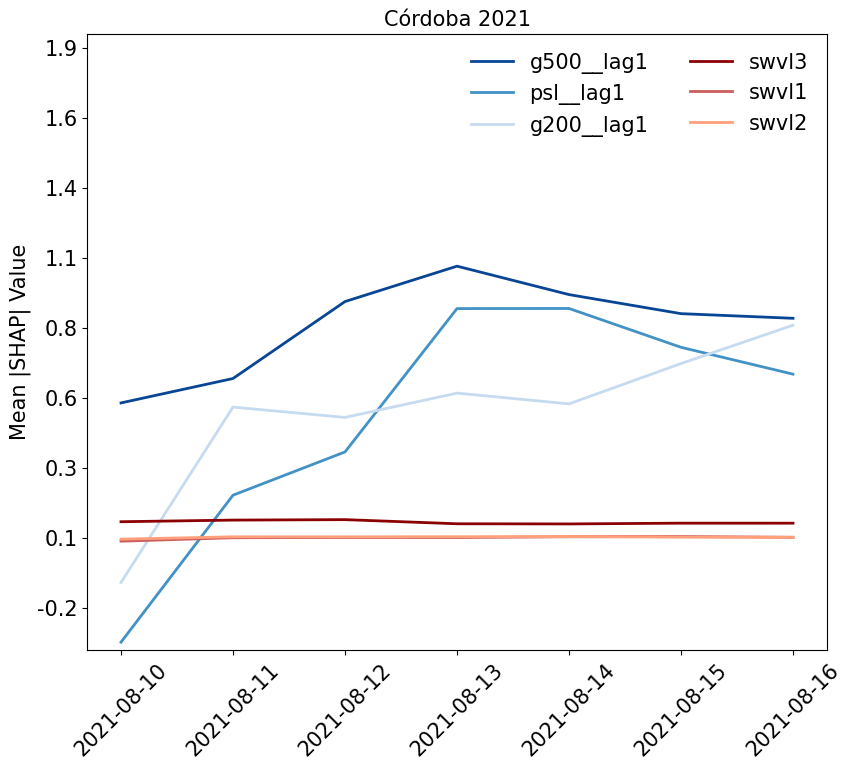

In [7]:
## import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.gridspec as gridspec
lat = np.arange(14, 72, 1)
lon = np.arange(-54, 71, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files_anomalies = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g200_1x1_lagged_standarized_anomalies.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_psl_1x1_lagged_standarized_anomalies.nc",  "psl"),
}

files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/g500_era5_data_full_domain_1950_2024.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/data/era5/g200_era5_data_full_domain_1950_2024.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/data/era5/psl_era5_data_full_domain_1950_2024.nc",  "psl"),
}



var = 'g500'
ds_anomalies = xr.open_dataset(files_anomalies[var][0])
ds = xr.open_dataset(files[var][0])


variables = ['g500','g200','psl']


# Temporal evolution plot

fig = plt.figure(figsize=(12, 8))  # Increased height to accommodate new layout
# Create 2 rows, 2 columns (but bottom row will span both columns)
gs = gridspec.GridSpec(1, 1)


ax_ts = plt.subplot(gs[0])  # [left, bottom, width, height]

ax_ts.set_aspect('auto')
ax_ts.set_aspect(2.5)

cmap = plt.cm.GnBu

all_shap_values_atm = all_shap_values[:,4:]
mean_abs_shap_atm = np.abs(all_shap_values_atm).mean(axis=0)
cleaned_names_atm = cleaned_names[4:]
sorted_indices_atm = np.argsort(mean_abs_shap_atm[:])[::-1] 

atm_colors = ["#084594", "#4292c6", "#c6dbef"]

norm = mcolors.Normalize(vmin=mean_abs_shap_atm.min(), vmax=mean_abs_shap_atm.max())

for count,i in enumerate(sorted_indices_atm[:3]):
    print(i)
    color = atm_colors[count]
    ax_ts.plot(target_dates_d, all_shap_values_atm[:, i], label=cleaned_names_atm[i], color=color, linewidth=2)


all_shap_values_land = all_shap_values[:,1:4]
mean_abs_shap_land = np.abs(all_shap_values_land).mean(axis=0)  # Note corrected slicing
cleaned_names_land = cleaned_names[1:4]
sorted_indices_land = np.argsort(mean_abs_shap_land[:])[::-1] 
cmap = plt.cm.Reds

count_plot = 0
colors_land = ["#CD5C5C","#FFA07A","#8B0000"]
for i in sorted_indices_land:  # indices 0 to 2 for features 1,2,3 in sliced array
    color = cmap(norm(mean_abs_shap_land[i]))
    clean_name = cleaned_names_land[i].removesuffix('_')
    ax_ts.plot(target_dates_d, all_shap_values_land[:, i], label=clean_name, color=colors_land[i], linewidth=2)
    count_plot += 1


#ax_ts.set_xlabel("Sample",fontsize=15)
ax_ts.set_ylabel("Mean |SHAP| Value",fontsize=15)
#ax_ts.set_ylim(-0.4,1.85)
ax_ts.set_title("Córdoba 2021",fontsize=15)
ax_ts.grid(False)
ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
yticks = np.arange(-0.4, 2, 0.25)
ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)
ax_ts.set_ylim(-0.4, 1.8)
ax_ts.legend(frameon=False,fontsize=15,ncol=2)
plt.savefig("../input_data/arnau-tfm/plots/SHAP_values_Gradient/temporal_SHAP_presentation_cordoba.png")

## Temporal Evolution Giff for the presentation

In [27]:
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter

def format_geopotential(x):
    return f"{x/100:.0f}"  # Divides by 100 and shows no decimals

def filter_small_regions(mask, min_size=2):
    """Filter out regions smaller than min_size connected pixels"""
    labeled_array, num_features = label(mask)
    for i in range(1, num_features+1):
        if np.sum(labeled_array == i) < min_size:
            mask[labeled_array == i] = False
    return mask


lat = np.arange(14, 72, 1)
lon = np.arange(-54, 70, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files_anomalies = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc", "g500"),
}

files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/g500_era5_data_full_domain_1950_2024.nc", "g500"),
}


variables = ['g500']

# First, compute percentiles for all samples

shap_percentiles = np.percentile(shap_values_cnn_study_case[:,:,:,:], [2, 98], axis=(2,3))
shap_percentiles_up = shap_percentiles[1]
shap_percentiles_down = shap_percentiles[0]
    
# Define thershold for the percentiles to avoid noise contours
threshold_percentile = 0.002


thresholds = {'g500':0.008,'g200':0.005,'psl':0.004}

# We'll need to precompute ERA5 percentiles for each variable
era5_percentiles = {}

j = 0
i = 0

central_lon = ( -54 + 70 ) / 2  
central_lat = ( 14 + 71 ) / 2   
map_extent = [-54, 70, 14, 71]


# Modified plotting loop
for (title_a, (file_a, var_a)),(title, (file, var)) in zip(files_anomalies.items(),files.items()):


    os.makedirs("temp_frames", exist_ok=True)

    ds_anomalies = xr.open_dataset(file_a)
    ds = xr.open_dataset(file)

    era_percentiles = []

    vari = f'lagged_era5{var_a}_anomalies_lag{1}'
        
    # Load all time steps for this variable
    era_data_anomalies = ds_anomalies[vari].sel(time=slice("2021-08-10", f"2021-08-{10+n_samples-1}")).values
    era_data = ds[var].sel(time=slice("2021-08-10", f"2021-08-{10+n_samples-1}")).values
    
        
    # era_data -->  Shape: (time, lat, lon)
    # era_data_anomalies --> Shape: (time, lat, lon)
   
    output_frames = []

    print(var)

    for s in range(n_samples):
    # This correctly creates two side-by-side subplots
        fig = plt.figure(figsize=(15, 6))

        # 2. Define the grid layout for the subplots
        gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])
    
        # 3. Create each subplot individually, applying projection ONLY where needed
    
        # The first subplot is a standard Axes for the time series (no projection)
        ax_ts = fig.add_subplot(gs[0, 0])
    
        # Define the map projection once to reuse it
        map_projection = ccrs.LambertConformal(
            central_longitude=central_lon,
            central_latitude=central_lat,
            standard_parallels=(30, 60)
        )
    
        # The second and third subplots are GeoAxes with the map projection
        ax_shap = fig.add_subplot(gs[0, 1], projection=map_projection)
        ax_era = fig.add_subplot(gs[0, 2], projection=map_projection)
        
        

        ax_ts.set_aspect('auto')
        ax_ts.set_aspect(2.5)
        
        cmap = plt.cm.GnBu
        
        all_shap_values_atm = all_shap_values[:,4:]
        mean_abs_shap_atm = np.abs(all_shap_values_atm).mean(axis=0)
        cleaned_names_atm = cleaned_names[4:]
        sorted_indices_atm = np.argsort(mean_abs_shap_atm[:])[::-1] 
        
        atm_colors = ["#084594", "#4292c6", "#c6dbef"]
        
        norm = mcolors.Normalize(vmin=mean_abs_shap_atm.min(), vmax=mean_abs_shap_atm.max())
        
        for count,i in enumerate(sorted_indices_atm[:3]):
            print(i)
            color = atm_colors[count]
            ax_ts.plot(target_dates_d, all_shap_values_atm[:, i], label=cleaned_names_atm[i], color=color, linewidth=2)
        
        
        all_shap_values_land = all_shap_values[:,1:4]
        mean_abs_shap_land = np.abs(all_shap_values_land).mean(axis=0)  # Note corrected slicing
        cleaned_names_land = cleaned_names[1:4]
        sorted_indices_land = np.argsort(mean_abs_shap_land[:])[::-1] 
        cmap = plt.cm.Reds
        
        count_plot = 0
        colors_land = ["#CD5C5C","#FFA07A","#8B0000"]
        for i in sorted_indices_land:  # indices 0 to 2 for features 1,2,3 in sliced array
            color = cmap(norm(mean_abs_shap_land[i]))
            clean_name = cleaned_names_land[i].removesuffix('_')
            ax_ts.plot(target_dates_d, all_shap_values_land[:, i], label=clean_name, color=colors_land[i], linewidth=2)
            count_plot += 1
        
        
        #ax_ts.set_xlabel("Sample",fontsize=15)
        ax_ts.set_ylabel("Mean |SHAP| Value",fontsize=15)
        #ax_ts.set_ylim(-0.4,1.85)
        ax_ts.set_title("Córdoba 2021",fontsize=15)
        ax_ts.grid(False)
        ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
        yticks = np.arange(-0.4, 2, 0.25)
        ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)
        ax_ts.set_ylim(-0.4, 1.8)
        ax_ts.legend(frameon=False,fontsize=10,ncol=2)
                
   

        vari = f'lagged_era5{var}_anomalies_lag{1}'
        data_era_anomalies = ds_anomalies[vari].sel(time=f"2021-08-{10+s}").squeeze()
        data_era = ds[var].sel(time=f"2021-08-{10+s}").squeeze()

        
        era_values_anomalies = data_era_anomalies.values
        era_values = data_era.values

        
        if s==3:
           s=4
        elif s==4:
           s=3
        else:
           pass
            
        # ===== TOP ROW: SHAP VALUES =====
   
        data = shap_values_cnn_study_case[s, 0, :, :]
        da = xr.DataArray(data, dims=["lat", "lon"], coords=dict(lat=lat, lon=lon))

        # Apply threshold mask
        threshold = thresholds[var]
        mask = np.abs(da) > threshold
        da_filtered = da.where(mask, 0)


        if s==4:
           s=3
        elif s==3:
           s=4
        else:
           pass

        # Plot with contourf
        data_smooth = gaussian_filter(da_filtered.values, sigma=0.7)

        cmap = plt.get_cmap("coolwarm") 
        img_shap = da_filtered.plot.contourf(
            ax=ax_shap,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            levels=40,
            add_colorbar=False,
            vmin=-0.02,
            vmax=0.02
        )


        ax_shap.coastlines()
        ax_shap.set_title(cnn_feature_names[0], fontsize=10)
        ax_shap.set_xticks([])
        ax_shap.set_yticks([])

   
        # ===== BOTTOM ROW: ERA5 ANOMALIES =====


        img_era = data_era_anomalies.plot.pcolormesh(
            ax=ax_era,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            add_colorbar=False,
            add_labels=False,
            vmin = -3.,
            vmax = 3.
        )

        data_era['lat'].attrs = {}
        data_era['lon'].attrs = {}

        contour_interval = 400  # Adjust this value as needed

        # Calculate levels based on your data range
        min_val = float(data_era.min())
        #print(f"Min value data era for {var}:{min_val}")
        max_val = float(data_era.max())
        #print(f"Max value data era for {var}:{max_val}")
        
        # Create levels with fixed interval
        levels = np.arange(
            min_val,
            max_val,
            contour_interval
        )

        # Add black contour lines for the ERA5 data
        contours = data_era.plot.contour(
            ax=ax_era,
            transform=ccrs.PlateCarree(),
            colors='black',
            linewidths=0.5,
            levels=levels  # Should match the number in contourf
        )

        ax_era.set_xlabel("")
        ax_era.set_ylabel("")

        ax_era.coastlines()
        ax_era.set_title(f"{var} anomalies (lag 1)", fontsize=10)
        ax_era.set_xticks([])
        ax_era.set_yticks([])


       
        ax_era.set_ylabel("Latitude")
    
        ax_era.set_xlabel("Longitude")
                
        ax_era.clabel(contours, inline=True, fontsize=6, fmt=format_geopotential)

        for spine in ax_era.spines.values():
            spine.set_visible(False)



        # ===== COLORBARS AND FINAL TOUCHES =====

                   
        cbar_ax1 = fig.add_axes([0.413, 0.2, 0.2, 0.02])  # Adjusted position
        cbar1 = fig.colorbar(img_shap, cax=cbar_ax1, orientation='horizontal')
        cbar1.set_label("SHAP Value", fontsize=15)
        
        # Define ticks and custom labels
        ticks = [-0.02, -0.01, 0, 0.01, 0.02]
        labels = ["-0.02", "-0.01", "0", "0.01", "0.02"]
        
        cbar1.set_ticks(ticks)
        cbar1.set_ticklabels(labels)
        cbar1.ax.tick_params(labelsize=14)
        
        # Left of ERA5 plot
        cbar_ax2 = fig.add_axes([0.685, 0.2, 0.2, 0.02])  # Adjusted position
        cbar2 = fig.colorbar(img_era, cax=cbar_ax2, orientation='horizontal')
        cbar2.set_label(f"Standarized Anomalies",fontsize=15)
        cbar2.ax.tick_params(labelsize=14)

        ticks = [-3, -2,-1,  0, 1, 2, 3]
        labels = ["-3", "-2", "-1", "0", "1", "2", "3"]

        cbar2.set_ticks(ticks)
        cbar2.set_ticklabels(labels)
        cbar2.ax.tick_params(labelsize=14)

        fig.suptitle(f"Sample {s+1}/{n_samples} - {var.upper()}\n Date:2021-08-{10+s} )",
                     fontsize=12, x=0.5,y=0.85)

        frame_path = f"temp_frames/frame_{s:03d}.png"
        plt.savefig(frame_path, bbox_inches='tight', dpi=150)
        #plt.show()
        plt.close()
        try:
            img = Image.open(frame_path)
            if not output_frames:
                target_size = img.size  # (width, height)
            img_resized = img.resize(target_size)
            output_frames.append(np.array(img_resized))
            img.close()
        except Exception as e:
            print(f"Error reading frame {frame_path}: {e}")

    # Create GIF
    imageio.mimsave(f"temporal_shap_presentation_{var}_{site}_highlighted_per_sample.gif", output_frames, fps=0.3)
    shutil.rmtree("temp_frames")

    print(f"Finished var : {var}")

    j += 3
    i += 1

g500
0
6
3


/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)


0
6
3


/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)


0
6
3


...

0
6
3


/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)


0
6
3


/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
/scratch/tmp/22985606/ipykernel_3522402/2854831166.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_yticklabels([f"{y:.1f}" for y in yticks], rotation=0, fontsize=15)


Finished var : g500


# Plot main text: tempeoral evolution circulation + frame of spatial importance 

/scratch/tmp/31378709/ipykernel_2615566/4047257239.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)


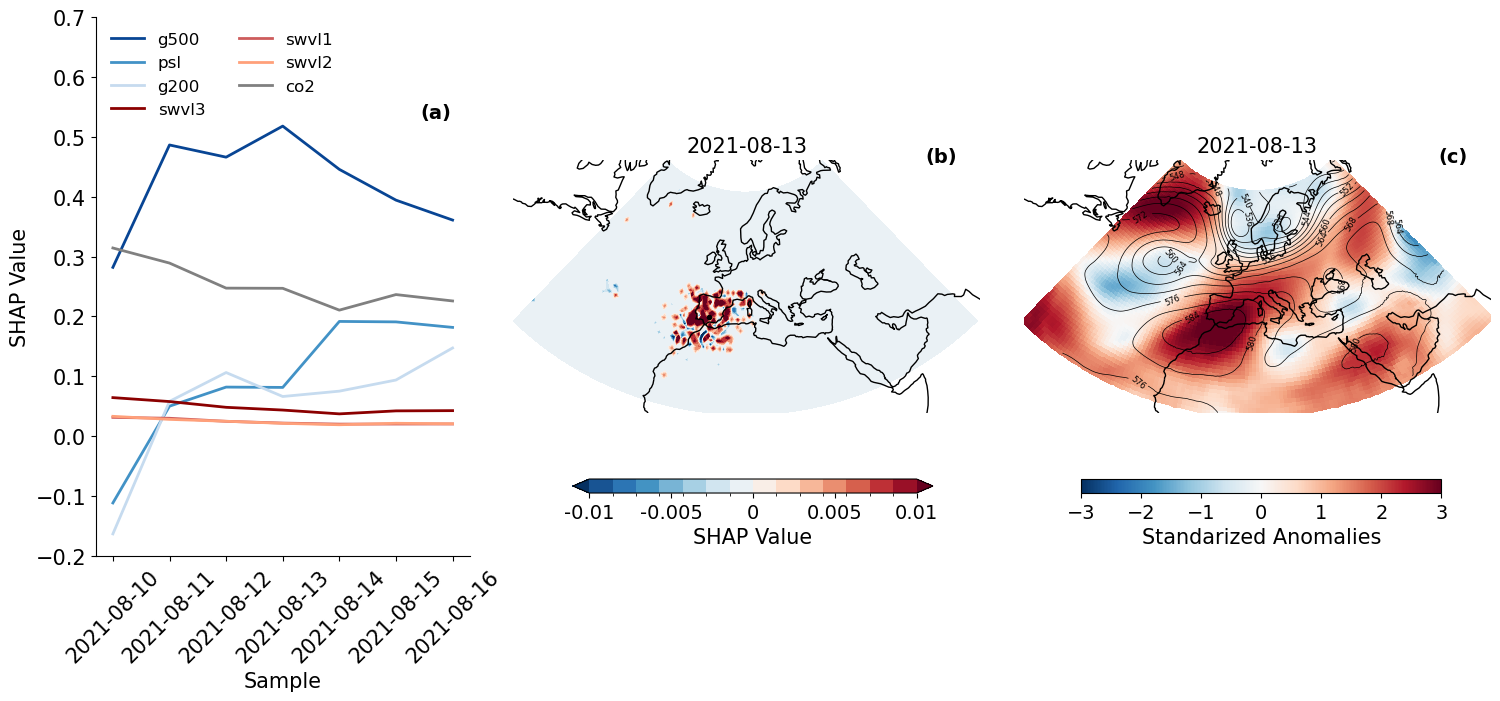

In [11]:
## import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.ndimage import gaussian_filter

import matplotlib.gridspec as gridspec
lat = np.arange(14, 72, 1)
lon = np.arange(-54, 70, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files_anomalies = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g200_1x1_lagged_standarized_anomalies.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_psl_1x1_lagged_standarized_anomalies.nc",  "psl"),
}

files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/data/era5/g500_era5_data_full_domain_1950_2024.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/data/era5/g200_era5_data_full_domain_1950_2024.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/data/era5/psl_era5_data_full_domain_1950_2024.nc",  "psl"),
}



var = 'g500'
ds_anomalies = xr.open_dataset(files_anomalies[var][0])
ds = xr.open_dataset(files[var][0])


variables = ['g500','g200','psl']

#variables = ['g500']

# First, compute percentiles for all samples

shap_percentiles = np.percentile(shap_values_cnn_study_case[:,:,:,:], [2, 98], axis=(2,3))
shap_percentiles_up = shap_percentiles[1]
shap_percentiles_down = shap_percentiles[0]
    
# Define thershold for the percentiles to avoid noise contours
threshold_percentile = 0.002


#shap_percentiles_up = np.stack(shap_percentiles_up,axis=0) 
#shap_percentiles_down = np.stack(shap_percentiles_down,axis=0)


thresholds = {'g500':0.009,'g200':0.005,'psl':0.004}

# We'll need to precompute ERA5 percentiles for each variable
era5_percentiles = {}

j = 0
i = 0

central_lon = ( -54 + 70 ) / 2  
central_lat = ( 14 + 71 ) / 2   
map_extent = [-54, 70, 14, 71]

# ---- Plotting ----
fig = plt.figure(figsize=(18, 7))  # Increased height to accommodate new layout
# Create 2 rows, 2 columns (but bottom row will span both columns)
gs = gridspec.GridSpec(1, 3, width_ratios=[0.8, 1, 1], wspace=0.1,hspace=0.3)

central_lon = (lon[0] + lon[-1]) / 2
central_lat = (lat[0] + lat[-1]) / 2
map_proj = ccrs.LambertConformal(central_longitude=central_lon, central_latitude=central_lat, standard_parallels=(30, 60))
map_extent = [-54, 70, 14, 71]

# --- Top-left: SHAP Spatial Plot ---

# ------------------------------------------------------------------------------------------------------ç

data = shap_values_cnn_study_case[5, 0, :, :]
da = xr.DataArray(data, dims=["lat", "lon"], coords=dict(lat=lat, lon=lon))
threshold = thresholds["g500"]
mask = np.abs(da) > threshold
da_filtered = da.where(mask, 0)

ax_shap = plt.subplot(gs[0, 1], projection=map_proj)
img_shap = da_filtered.plot.contourf(
    ax=ax_shap,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    levels=15,
    add_colorbar=False,
    add_labels=False,
    vmin=-0.02,
    vmax=0.02
)
ax_shap.coastlines()
#ax_shap.set_title("SHAP values g500_lag1")
ax_shap.set_extent(map_extent, crs=ccrs.PlateCarree())

# --- Top-right: ERA5 Anomalies Map ---

vari = 'lagged_era5g500_anomalies_lag1'
data_era_anomalies = ds_anomalies[vari].sel(time=f"2021-08-{15}").squeeze()
data_era = ds[var].sel(time=f"2021-08-{15}").squeeze()


era_values_anomalies = data_era_anomalies.values
era_values = data_era.values / 9.78 #divide by approx g to convert to geopotential height

ax_era = plt.subplot(gs[0, 2], projection=map_proj)
img_era = data_era_anomalies.plot.pcolormesh(
    ax=ax_era,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    add_colorbar=False,
    add_labels=False,
    vmin=-3.,
    vmax=3.
)
ax_era.coastlines()
#ax_era.set_title(f"Standarized Anomalies g500")
ax_era.set_extent(map_extent, crs=ccrs.PlateCarree())


# Optional: Add geopotential contours
contour_interval = 400
levels = np.arange(float(data_era.min()), float(data_era.max()), contour_interval)
contours = data_era.plot.contour(
    ax=ax_era,
    transform=ccrs.PlateCarree(),
    colors='black',
    linewidths=0.5,
    levels=levels
)
ax_era.clabel(contours, inline=True, fontsize=6, fmt=lambda x: f"{x/100:.0f}")

for spine in ax_era.spines.values():
    spine.set_visible(False)

for spine in ax_shap.spines.values():
    spine.set_visible(False)


# --- Colorbars ---
# Left of SHAP plot
cbar_ax1 = fig.add_axes([0.39, 0.2, 0.2, 0.02])  # Adjusted position
cbar1 = fig.colorbar(img_shap, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label("SHAP Value", fontsize=15)

# Define ticks and custom labels
ticks = [-0.02, -0.01, 0, 0.01, 0.02]
labels = ["-0.01", "-0.005", "0", "0.005", "0.01"]

cbar1.set_ticks(ticks)
cbar1.set_ticklabels(labels)
cbar1.ax.tick_params(labelsize=14)

# Left of ERA5 plot
cbar_ax2 = fig.add_axes([0.6725, 0.2, 0.2, 0.02])  # Adjusted position
cbar2 = fig.colorbar(img_era, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label(f"Standarized Anomalies",fontsize=15)
cbar2.ax.tick_params(labelsize=14)

# Temporal evolution plot 


ax_ts = plt.subplot(gs[0, 0])  # [left, bottom, width, height]



cmap = plt.cm.GnBu

cleaned_names = [name.replace('__lag1', '') for name in cleaned_names]

total_shap_sample = np.abs(all_shap_values).sum(axis=1)
all_shap_values_main_fig = all_shap_values / total_shap_sample * 100

all_shap_values_atm = all_shap_values[:,4:]
mean_abs_shap_atm = np.abs(all_shap_values_atm).mean(axis=0)
cleaned_names_atm = cleaned_names[4:]
sorted_indices_atm = np.argsort(mean_abs_shap_atm[:])[::-1] 

atm_colors = ["#084594", "#4292c6", "#c6dbef"]

norm = mcolors.Normalize(vmin=mean_abs_shap_atm.min(), vmax=mean_abs_shap_atm.max())

for count,i in enumerate(sorted_indices_atm[:3]):
    color = atm_colors[count]
    ax_ts.plot(target_dates_d, all_shap_values_atm[:, i] / total_shap_sample  , label=cleaned_names_atm[i], color=color, linewidth=2)


all_shap_values_land = all_shap_values[:,1:4]
mean_abs_shap_land = np.abs(all_shap_values_land).mean(axis=0)  # Note corrected slicing
cleaned_names_land = cleaned_names[1:4]
sorted_indices_land = np.argsort(mean_abs_shap_land[:])[::-1] 
cmap = plt.cm.Reds

count_plot = 0
colors_land = ["#CD5C5C","#FFA07A","#8B0000"]
for i in sorted_indices_land:  # indices 0 to 2 for features 1,2,3 in sliced array
    color = cmap(norm(mean_abs_shap_land[i]))
    clean_name = cleaned_names_land[i].removesuffix('_')
    ax_ts.plot(target_dates_d, all_shap_values_land[:, i] / total_shap_sample , label=clean_name, color=colors_land[i], linewidth=2)
    count_plot += 1

# Plot CO2 in time evolution as well 

shap_co2 = all_shap_values[:,0] / total_shap_sample 
#plot co2 shap time series value with gray color
ax_ts.plot(target_dates_d, shap_co2, label="co2", color="gray", linewidth=2)



ax_ts.set_xlabel("Sample",fontsize=15)
ax_ts.set_ylabel("SHAP Value",fontsize=15)
#ax_ts.set_title("Temporal Evolution of Atmosphere SHAP")
ax_ts.grid(False)

ax_ts.set_xticklabels(target_dates_plot, rotation=45,fontsize=15)
ax_ts.set_ylim(-0.2, 0.7)
ax_ts.tick_params(axis='y', labelsize=15)

ax_ts.legend(fontsize="large", loc="upper left", ncol=2, frameon=False)

i=1
for spine in ax_ts.spines.values():
    if i%2 == 0:
        spine.set_visible(False)
    i += 1

ax_era.set_title("2021-08-13",fontsize=15)
ax_shap.set_title("2021-08-13",fontsize=15)


# Panels text ------------------------------------------------------------------------------

ax_shap.text(0.95, 1.05, '(b)', transform=ax_shap.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='right')

ax_era.text(0.95, 1.05, '(c)', transform=ax_era.transAxes, 
           fontsize=14, fontweight='bold', va='top', ha='right')

ax_ts.text(0.95, 0.84, '(a)', transform=ax_ts.transAxes, 
          fontsize=14, fontweight='bold', va='top', ha='right')

# Córdoba location
hannover_lon = -4.782039
hannover_lat = 37.886520
ax_shap.plot(hannover_lon, hannover_lat, 'o', color='black', markersize=3, transform=ccrs.Geodetic(), zorder=10)


# --- Final Touches ---
#fig.suptitle("SHAP temporal evolution and spatial distribution study case Córdoba", fontsize=14)
plt.savefig("../input_data/arnau-tfm/plots/SHAP_values_Gradient/nolags_90p_spatial_study_case_cordoba.pdf")

## ERA5 giff for top important feature, to follow the temporal evolution

## swvl[1,2,3] anomalies during that period 

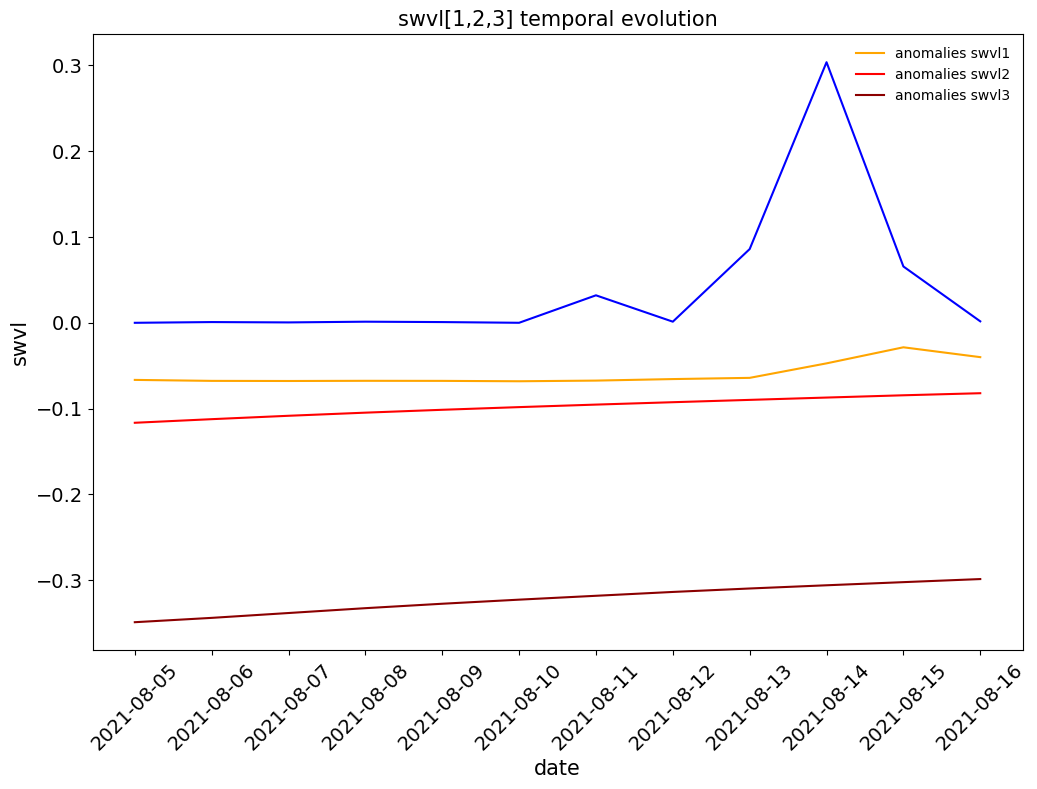

In [7]:
dates_1 = [f"2021-08-0{i}T11:30:00" for i in range(5,10)]
dates_2 = [f"2021-08-{i}T11:30:00" for i in range(10,17)]

target_dates_swvl = np.array(dates_1 + dates_2,dtype='datetime64[ns]')

indices_swvl = np.where(np.isin(dates, target_dates_swvl))[0]

explain_nn_np = explain_nn.cpu().numpy()[indices_swvl]
explain_cnn_np = explain_cnn.cpu().numpy()[indices_swvl]

colors = ['orange', 'red', 'darkred']


n_samples = explain_nn_np.shape[0]
samples = explain_nn_np[:,0]

vline_positions = np.arange(0, n_samples, 92)
year_centers = vline_positions[:] + 46 


target_dates_swvl = target_dates_swvl.astype('datetime64[D]')
target_dates_swvl_plot = target_dates_swvl.astype('O') 


# swvl[1,2,3] anomalies data ------------------------------------------------------------------------------------------------------------------

ds_swvl = xr.open_dataset(f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc").sel(time=slice('2014-01-01','2024-12-31'))
ds_swvl = ds_swvl.sel(time=ds_swvl.time.dt.month.isin([6,7,8]))


# Dates treatment 

dates_swvl = ds_swvl['time'].values
date_to_remove = np.datetime64('2024-07-31', 'D')
mask = dates_swvl.astype('datetime64[D]') != date_to_remove
dates_swvl = dates_swvl[mask]

target_dates_swvl = np.array(dates_1 + dates_2,dtype='datetime64[ns]')
indices_swvl = np.where(np.isin(dates, target_dates_swvl))[0]


# Data

swvl1 = ds_swvl['swvl1_anomalies'].values[mask][indices_swvl]
swvl2 = ds_swvl['swvl2_anomalies'].values[mask][indices_swvl]
swvl3 = ds_swvl['swvl3_anomalies'].values[mask][indices_swvl]

swvl_dict = {1:swvl1,2:swvl2,3:swvl3}

target_dates_swvl = target_dates_swvl.astype('datetime64[D]')
target_dates_swvl_plot = target_dates_swvl.astype('O') 

# Precipitation Data ---------------------------------------------------------------------------------------------------------------------------

file_precipitation = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/precipitation_era5land_data_cordoba_2003_2024.nc"
ds_prlr = xr.open_dataset(file_precipitation).sel(time=slice('2014-01-01','2024-12-31'))
ds_prlr = ds_prlr.sel(time=ds_prlr.time.dt.month.isin([6,7,8]))
prlr = ds_prlr['prlr'].values

dates_prlr = ds_prlr['time'].values
date_to_remove = np.datetime64('2024-07-31', 'D')
mask = dates_prlr.astype('datetime64[D]') != date_to_remove
dates_prlr = dates_prlr[mask]

target_dates_prlr = np.array(dates_1 + dates_2,dtype='datetime64[ns]')
indices_prlr = np.where(np.isin(dates, target_dates_prlr))[0]

prlr = prlr[mask]

prlr_study_case = prlr[indices_prlr]

target_dates_prlr = target_dates_prlr.astype('datetime64[D]')
target_dates_prlr_plot = target_dates_prlr.astype('O') 


# Plot the figure ----------------------------------------------------------------------------------------------------------------------


plt.figure(figsize=(12,8))

for i in range(1,4):

    swvl = swvl_dict[i]
    
    plt.plot(target_dates_swvl_plot,swvl,color=colors[i-1],label=f"anomalies swvl{i}")


plt.plot(target_dates_prlr_plot,prlr_study_case*1000*86400,color='blue')

  
plt.legend(frameon=False)
plt.title("swvl[1,2,3] temporal evolution",fontsize=15)    
plt.xlabel("date",fontsize=15)
plt.ylabel("swvl",fontsize=15)
plt.xticks(ticks=target_dates_prlr_plot, 
           labels=[d.strftime('%Y-%m-%d') for d in target_dates_prlr_plot],
           rotation=45,
           fontsize=14)
plt.yticks(fontsize=14)

plt.show()    

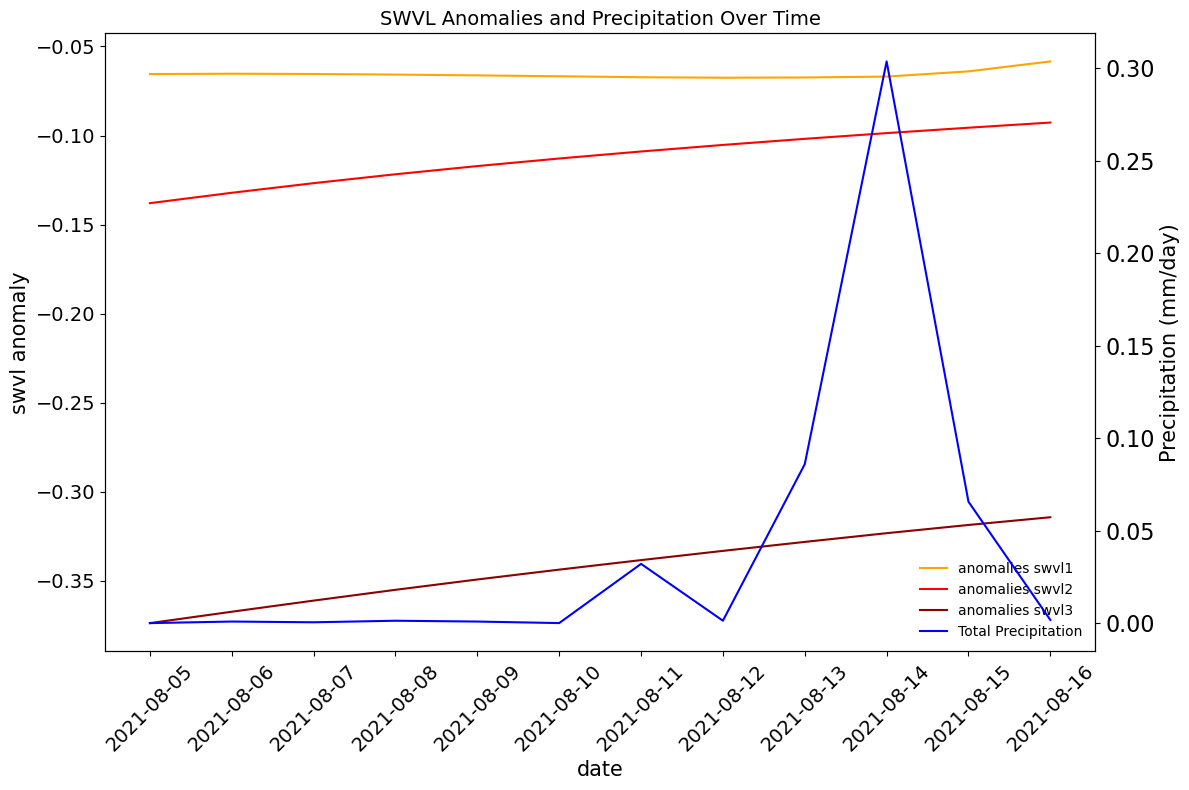

In [8]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 8))

colors = ['orange', 'red', 'darkred']

for i in range(1, 4):
    swvl = explain_nn_np[:, i]
    ax1.plot(target_dates_swvl_plot, swvl, color=colors[i - 1], label=f"anomalies swvl{i}")

ax1.set_xlabel("date", fontsize=15)
ax1.set_ylabel("swvl anomaly", fontsize=15, color='black')
ax1.tick_params(axis='y', labelcolor='black',labelsize=14)
ax1.tick_params(axis='x', rotation=45, labelsize=14)
ax1.set_xticks(target_dates_swvl_plot)
ax1.set_xticklabels([d.strftime('%Y-%m-%d') for d in target_dates_swvl_plot], fontsize=14)

ax2 = ax1.twinx()

ax2.plot(target_dates_prlr_plot, prlr_study_case * 1000 * 86400, color='blue', label="Total Precipitation")
ax2.set_ylabel("Precipitation (mm/day)", fontsize=15, color='black')
ax2.tick_params(axis='y', labelcolor='black',labelsize=16)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False)

plt.title("SWVL Anomalies and Precipitation Over Time", fontsize=14)
plt.tight_layout()
plt.show()


## Precipitation anomalies during that period 

## Spatial distribution SHAP values 

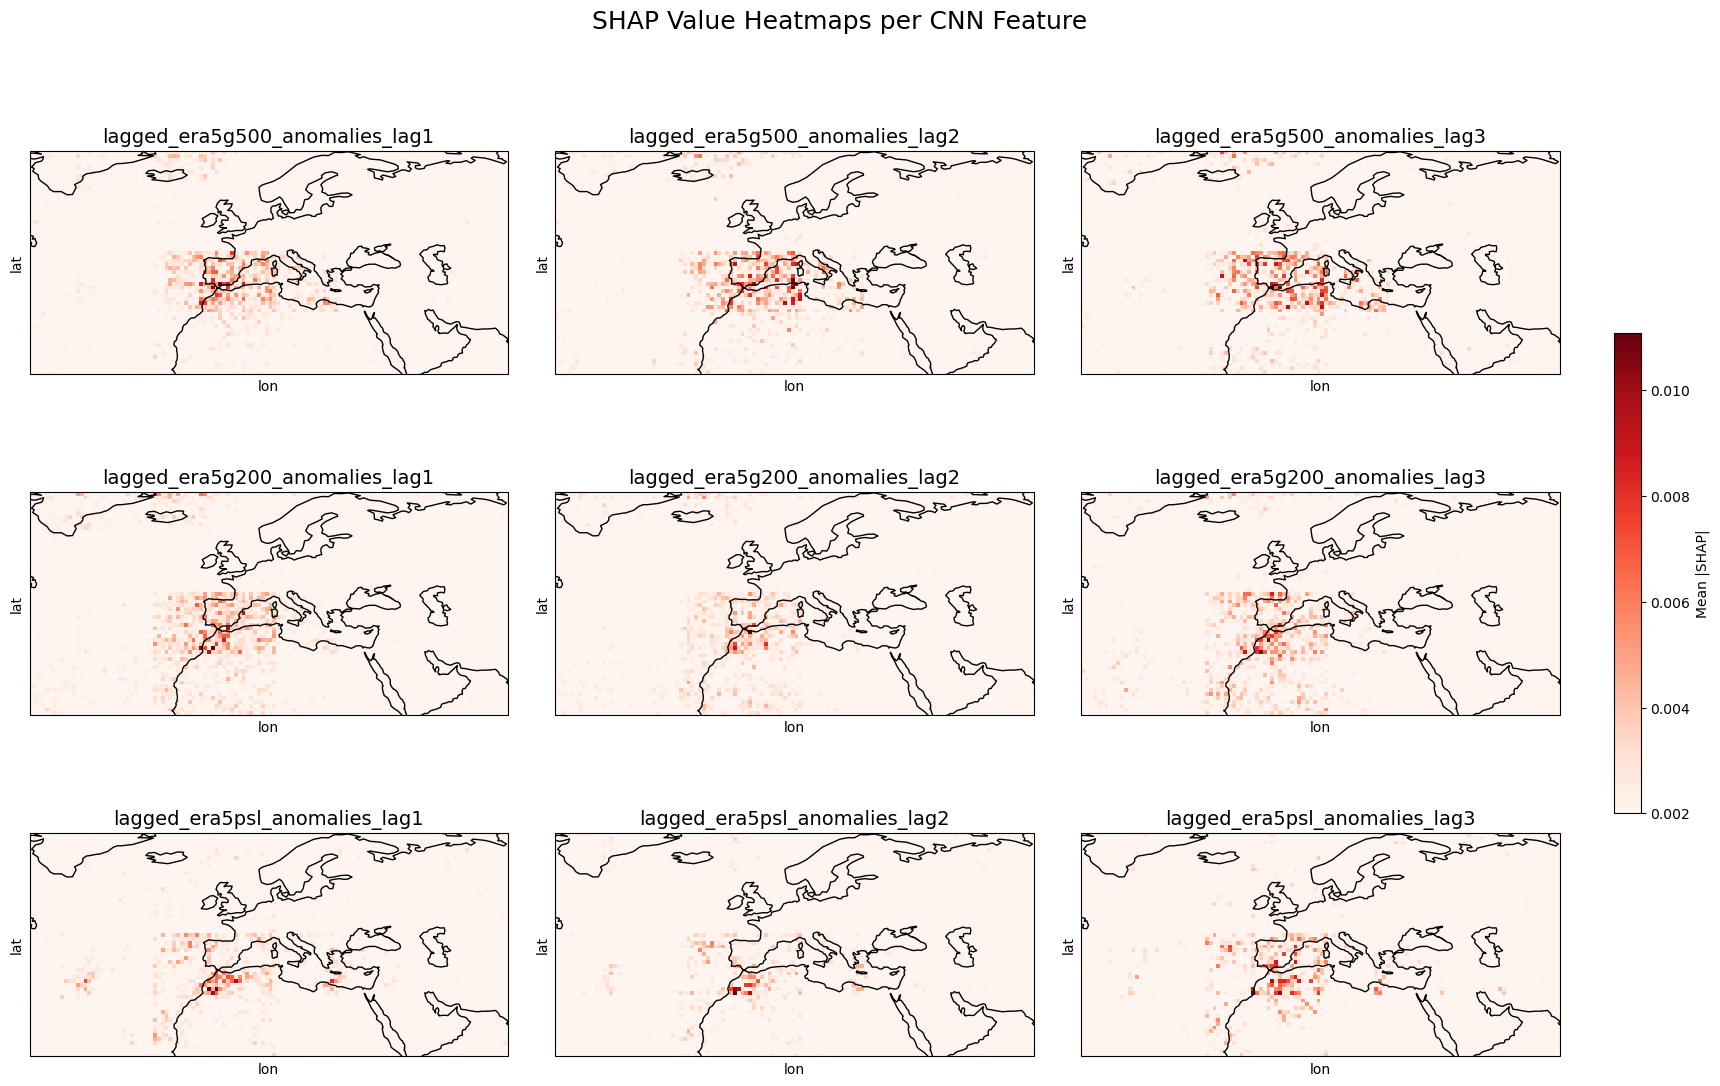

In [8]:
lat = np.arange(14, 72, 1)
lon = np.arange(-54, 70, 1)

fig, axes = plt.subplots(3, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()


for i in range(9):
    ax = axes[i]
    
    data = shap_values_cnn_study_case[:, i, :, :]

    
    da = xr.DataArray(abs(data), dims=["sample", "lat", "lon"],
                      coords=dict(lat=lat, lon=lon))

    threshold = 0.00  # adjust based on your data

    # Mask small values before plotting
    da_filtered = da.mean("sample").where(np.abs(da.mean("sample")) > threshold)

# RdBu_r
    
    
    img = da_filtered.plot(
        ax=ax,
        cmap="Reds",
        add_colorbar=False,
        vmin=0.002,
        #vmax=0.04
    )

    ax.coastlines()
    ax.set_title(cnn_feature_names[i], fontsize=14)
    ax.set_xticks([])  # optional: remove ticks
    ax.set_yticks([])

# Add shared colorbar
cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4])
fig.colorbar(img, cax=cbar_ax, label="Mean |SHAP|")

# Reduce spacing
plt.subplots_adjust(left=0.05, right=0.9, top=0.9, bottom=0.05, hspace=0.01, wspace=0.1)
plt.suptitle("SHAP Value Heatmaps per CNN Feature", fontsize=18, y=0.97)
plt.show()

### Contours per sample, to track features in the map

In [8]:
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter



def format_geopotential(x):
    return f"{x/100:.0f}"  # Divides by 100 and shows no decimals

def filter_small_regions(mask, min_size=2):
    """Filter out regions smaller than min_size connected pixels"""
    labeled_array, num_features = label(mask)
    for i in range(1, num_features+1):
        if np.sum(labeled_array == i) < min_size:
            mask[labeled_array == i] = False
    return mask


lat = np.arange(14, 72, 1)
lon = np.arange(-54, 70, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files_anomalies = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc", "g500"),
}

files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/g500_era5_data_full_domain_1950_2024.nc", "g500"),
}


variables = ['g500']

# First, compute percentiles for all samples

shap_percentiles = np.percentile(shap_values_cnn_study_case[:,:,:,:], [2, 98], axis=(2,3))
shap_percentiles_up = shap_percentiles[1]
shap_percentiles_down = shap_percentiles[0]
    
# Define thershold for the percentiles to avoid noise contours
threshold_percentile = 0.002


thresholds = {'g500':0.009,'g200':0.005,'psl':0.004}

# We'll need to precompute ERA5 percentiles for each variable
era5_percentiles = {}

j = 0
i = 0

central_lon = ( -54 + 70 ) / 2  
central_lat = ( 14 + 71 ) / 2   
map_extent = [-54, 70, 14, 71]


# Modified plotting loop
for (title_a, (file_a, var_a)),(title, (file, var)) in zip(files_anomalies.items(),files.items()):


    os.makedirs("temp_frames", exist_ok=True)

    ds_anomalies = xr.open_dataset(file_a)
    ds = xr.open_dataset(file)

    era_percentiles = []

    vari = f'lagged_era5{var_a}_anomalies_lag{1}'
        
    # Load all time steps for this variable
    era_data_anomalies = ds_anomalies[vari].sel(time=slice("2021-08-10", f"2021-08-{10+n_samples-1}")).values
    era_data = ds[var].sel(time=slice("2021-08-10", f"2021-08-{10+n_samples-1}")).values
    
        
    # era_data -->  Shape: (time, lat, lon)
    # era_data_anomalies --> Shape: (time, lat, lon)
   
    output_frames = []

    print(var)

    for s in range(n_samples):
        if s==3:
            s=4
        elif s==4:
            s=3
        else:
            pass
            
        fig, axes = plt.subplots(2, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.LambertConformal(
                 central_longitude=central_lon,
                 central_latitude=central_lat,
                 standard_parallels=(30, 60))})
        axes = axes.flatten()

        # ===== TOP ROW: SHAP VALUES =====
   
        ax_shap = axes[0]
        print(s)
        data = shap_values_cnn_study_case[s, 0, :, :]
        da = xr.DataArray(data, dims=["lat", "lon"], coords=dict(lat=lat, lon=lon))

        ax_era = axes[1]
        vari = f'lagged_era5{var}_anomalies_lag{1}'
        if s==4:
            s=3
        elif s==3:
            s=4
        else:
            pass
        data_era_anomalies = ds_anomalies[vari].sel(time=f"2021-08-{10+s}").squeeze()
        data_era = ds[var].sel(time=f"2021-08-{10+s}").squeeze()

        
        era_values_anomalies = data_era_anomalies.values
        era_values = data_era.values

        # Apply threshold mask
        threshold = thresholds[var]
        mask = np.abs(da) > threshold
        da_filtered = da.where(mask, 0)

        # Plot with contourf
        data_smooth = gaussian_filter(da_filtered.values, sigma=0.7)

        cmap = plt.get_cmap("coolwarm") 
        img_shap = da_filtered.plot.contourf(
            ax=ax_shap,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            levels=40,
            add_colorbar=False,
            vmin=-0.02,
            vmax=0.02
        )


        ax_shap.coastlines()
        ax_shap.set_title(cnn_feature_names[0], fontsize=10)
        ax_shap.set_xticks([])
        ax_shap.set_yticks([])

        # ===== BOTTOM ROW: ERA5 ANOMALIES =====


        img_era = data_era_anomalies.plot.pcolormesh(
            ax=ax_era,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            add_colorbar=False,
            add_labels=False,
            extend='both',
            vmin = -2.,
            vmax = 2.
        )

        data_era['lat'].attrs = {}
        data_era['lon'].attrs = {}

        contour_interval = 400  # Adjust this value as needed

        # Calculate levels based on your data range
        min_val = float(data_era.min())
        #print(f"Min value data era for {var}:{min_val}")
        max_val = float(data_era.max())
        #print(f"Max value data era for {var}:{max_val}")
        
        # Create levels with fixed interval
        levels = np.arange(
            min_val,
            max_val,
            contour_interval
        )

        # Add black contour lines for the ERA5 data
        contours = data_era.plot.contour(
            ax=ax_era,
            transform=ccrs.PlateCarree(),
            colors='black',
            linewidths=0.5,
            levels=levels  # Should match the number in contourf
        )

        ax_era.set_xlabel("")
        ax_era.set_ylabel("")

        ax_era.coastlines()
        ax_era.set_title(f"{var} anomalies (lag 1)", fontsize=10)
        ax_era.set_xticks([])
        ax_era.set_yticks([])


       
        ax_shap.set_ylabel("Latitude")
        ax_era.set_ylabel("Latitude")
    
        
     
        ax_era.set_xlabel("Longitude")
        
        ax_shap.set_xticklabels([])
        
        ax_era.clabel(contours, inline=True, fontsize=6, fmt=format_geopotential)

        for ax in [ax_shap, ax_era]:
            ax.set_extent(map_extent, crs=ccrs.PlateCarree())

            for spine in ax.spines.values():
                spine.set_visible(False)

        # ===== COLORBARS AND FINAL TOUCHES =====
        # SHAP colorbar (top)

        cbar_shap_ax = fig.add_axes([0.77, 0.58, 0.015, 0.3])
    
        cbar_shap = fig.colorbar(img_shap, cax=cbar_shap_ax, label="SHAP Values")

        ticks = [-0.02, -0.01, 0, 0.01, 0.02]
        labels = ["-0.02", "-0.01", "0", "0.01", "0.02"]
        
        cbar_shap.set_ticks(ticks)
        cbar_shap.set_ticklabels(labels)
        cbar_shap.ax.tick_params(labelsize=14)
                   
        # ERA5 colorbar (bottom)
        cbar_era_ax = fig.add_axes([0.77, 0.13, 0.015, 0.3])
        fig.colorbar(img_era, cax=cbar_era_ax, label=f"{var.upper()} Anomalies")

        plt.subplots_adjust(left=0.05, right=0.9, top=0.95, bottom=0.08, hspace=0.2, wspace=0.1)
        fig.suptitle(f"Sample {s+1}/{n_samples} - {var.upper()}\n Date:2021-08-{10+s} )",
                     fontsize=12, y=1.05)

        frame_path = f"temp_frames/frame_{s:03d}.png"
        plt.savefig(frame_path, bbox_inches='tight', dpi=150)
        #plt.show()
        plt.close()
        try:
            img = Image.open(frame_path)
            if not output_frames:
                target_size = img.size  # (width, height)
            img_resized = img.resize(target_size)
            output_frames.append(np.array(img_resized))
            img.close()
        except Exception as e:
            print(f"Error reading frame {frame_path}: {e}")

    # Create GIF
    imageio.mimsave(f"shap_animation_only_{var}_{site}_highlighted_per_sample.gif", output_frames, fps=0.3)
    shutil.rmtree("temp_frames")

    print(f"Finished var : {var}")

    j += 3
    i += 1

g500
0
1
2
4
3
5
6
Finished var : g500


In [8]:
import matplotlib.ticker as mticker


def format_geopotential(x):
    return f"{x/100:.0f}"  # Divides by 100 and shows no decimals

def filter_small_regions(mask, min_size=2):
    """Filter out regions smaller than min_size connected pixels"""
    labeled_array, num_features = label(mask)
    for i in range(1, num_features+1):
        if np.sum(labeled_array == i) < min_size:
            mask[labeled_array == i] = False
    return mask


lat = np.arange(14, 72, 1)
lon = np.arange(-54, 71, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files_anomalies = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g200_1x1_lagged_standarized_anomalies.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/psl_1x1_lagged_standarized_anomalies.nc",  "psl"),
}

files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/g500_era5_data_full_domain_1950_2024.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/g200_era5_data_full_domain_1950_2024.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/psl_era5_data_full_domain_1950_2024.nc",  "psl"),
}


#files = {
#    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc", "g500")
#}


variables = ['g500','g200','psl']

#variables = ['g500']

# First, compute percentiles for all samples

shap_percentiles = np.percentile(shap_values_cnn_study_case[:,:,:,:], [2, 98], axis=(2,3))
shap_percentiles_up = shap_percentiles[1]
shap_percentiles_down = shap_percentiles[0]
    
# Define thershold for the percentiles to avoid noise contours
threshold_percentile = 0.002


#shap_percentiles_up = np.stack(shap_percentiles_up,axis=0) 
#shap_percentiles_down = np.stack(shap_percentiles_down,axis=0)


thresholds = {'g500':0.005,'g200':0.005,'psl':0.004}

# We'll need to precompute ERA5 percentiles for each variable
era5_percentiles = {}

j = 0
i = 0

central_lon = ( -54 + 70 ) / 2  
central_lat = ( 14 + 71 ) / 2   
map_extent = [-54, 70, 14, 71]


# Modified plotting loop
for (title_a, (file_a, var_a)),(title, (file, var)) in zip(files_anomalies.items(),files.items()):


    os.makedirs("temp_frames", exist_ok=True)

    ds_anomalies = xr.open_dataset(file_a)
    ds = xr.open_dataset(file)
    era_data_anomalies = []
    era_data = []
    era_percentiles = []

    for n in range(3,6):
        vari = f'lagged_era5{var_a}_anomalies_lag{n-2}'
        
        # Load all time steps for this variable
        era_data_anomalies.append(ds_anomalies[vari].sel(time=slice("2021-08-11", f"2021-08-{10+n_samples-1}")).values)
        era_data.append(ds[var].sel(time=slice("2021-08-10", f"2021-08-{10+n_samples-1}")).values)
        
        
    era_data = np.stack(era_data, axis=1)  # Shape: (time, lags, lat, lon)
    era_data_anomalies = np.stack(era_data_anomalies, axis=1)  # Shape: (time, lags, lat, lon)

    
    #era5_percentiles[var] = np.percentile(era_data, [30, 70], axis=(2,3))

   
    output_frames = []

    for s in range(n_samples):
        fig, axes = plt.subplots(2, 3, figsize=(14, 7), subplot_kw={'projection': ccrs.LambertConformal(
                 central_longitude=central_lon,
                 central_latitude=central_lat,
                 standard_parallels=(30, 60))})
        axes = axes.flatten()

        # ===== TOP ROW: SHAP VALUES =====
        for m in range(0, 3):
            n = m + 3
            ax_shap = axes[m]
            data = shap_values_cnn_study_case[s, j+m, :, :]
            da = xr.DataArray(data, dims=["lat", "lon"], coords=dict(lat=lat, lon=lon))

            ax_era = axes[n]
            vari = f'lagged_era5{var}_anomalies_lag{n-2}'
            data_era_anomalies = ds_anomalies[vari].sel(time=f"2021-08-{10+s}").squeeze()
            data_era = ds[var].sel(time=f"2021-08-{10+s}").squeeze()

            
            era_values_anomalies = data_era_anomalies.values
            era_values = data_era.values

            # Set upper and lower percentile conditions 
            #shap_sig_up = (data > shap_up[s]) & (shap_up[s]>threshold_percentile)
            #shap_sig_down =  (data < shap_down[s]) & (np.abs(shap_down[s])>threshold_percentile)
            #shap_sig = shap_sig_up | shap_sig_down #join upper and lower percentile conditions 
 

            # Apply threshold mask
            threshold = thresholds[var]
            mask = np.abs(da) > threshold
            da_filtered = da.where(mask, 0)

            # Plot with contourf
            img_shap = da_filtered.plot.contourf(
                ax=ax_shap,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                levels=20,
                add_colorbar=False,
                vmin=-0.02,
                vmax=0.02
            )


            ax_shap.coastlines()
            ax_shap.set_title(cnn_feature_names[j+m], fontsize=10)
            ax_shap.set_xticks([])
            ax_shap.set_yticks([])

        # ===== BOTTOM ROW: ERA5 ANOMALIES =====


            img_era = data_era_anomalies.plot.pcolormesh(
                ax=ax_era,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                add_colorbar=False,
                add_labels=False,
                vmin = -2.,
                vmax = 2.
            )

            data_era['lat'].attrs = {}
            data_era['lon'].attrs = {}

            contour_interval = 400  # Adjust this value as needed

            # Calculate levels based on your data range
            min_val = float(data_era.min())
            #print(f"Min value data era for {var}:{min_val}")
            max_val = float(data_era.max())
            #print(f"Max value data era for {var}:{max_val}")
            
            # Create levels with fixed interval
            levels = np.arange(
                min_val,
                max_val,
                contour_interval
            )

            # Add black contour lines for the ERA5 data
            contours = data_era.plot.contour(
                ax=ax_era,
                transform=ccrs.PlateCarree(),
                colors='black',
                linewidths=0.5,
                levels=levels  # Should match the number in contourf
            )

            ax_era.set_xlabel("")
            ax_era.set_ylabel("")

            ax_era.coastlines()
            ax_era.set_title(f"{var} anomalies (lag {n-2})", fontsize=10)
            ax_era.set_xticks([])
            ax_era.set_yticks([])


            if m == 0:
                ax_shap.set_ylabel("Latitude")
                ax_era.set_ylabel("Latitude")
            else:
                ax_shap.set_yticklabels([])
                ax_era.set_yticklabels([])
            
            if m == 2:
                ax_era.set_xlabel("Longitude")
            else:
                ax_shap.set_xticklabels([])
                ax_era.set_xticklabels([])
            
            ax_era.clabel(contours, inline=True, fontsize=6, fmt=format_geopotential)

            for ax in [ax_shap, ax_era]:
                ax.set_extent(map_extent, crs=ccrs.PlateCarree())

                for spine in ax.spines.values():
                    spine.set_visible(False)

        # ===== COLORBARS AND FINAL TOUCHES =====
        # SHAP colorbar (top)

        cbar_shap_ax = fig.add_axes([0.92, 0.58, 0.02, 0.3])
    
        cbar_shap = fig.colorbar(img_shap, cax=cbar_shap_ax, label="SHAP Values")

        ticks = [-0.02, -0.01, 0, 0.01, 0.02]
        labels = ["< -0.02", "-0.01", "0", "0.01", "> 0.02"]
        
        cbar_shap.set_ticks(ticks)
        cbar_shap.set_ticklabels(labels)
        cbar_shap.ax.tick_params(labelsize=14)
                   

        # ERA5 colorbar (bottom)
        cbar_era_ax = fig.add_axes([0.92, 0.12, 0.02, 0.3])
        fig.colorbar(img_era, cax=cbar_era_ax, label=f"{var.upper()} Anomalies")

        plt.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.08, hspace=0.2, wspace=0.1)
        fig.suptitle(f"Sample {s+1}/{n_samples} - {var.upper()}\n Date:2021-08-{10+s} )",
                     fontsize=12, y=0.97)

        frame_path = f"temp_frames/frame_{s:03d}.png"
        plt.savefig(frame_path, bbox_inches='tight', dpi=150)
        #plt.show()
        plt.close()
        try:
            img = Image.open(frame_path)
            if not output_frames:
                target_size = img.size  # (width, height)
            img_resized = img.resize(target_size)
            output_frames.append(np.array(img_resized))
            img.close()
        except Exception as e:
            print(f"Error reading frame {frame_path}: {e}")

    # Create GIF
    imageio.mimsave(f"shap_animation_cnn_{var}_{site}_highlighted_per_sample.gif", output_frames, fps=0.3)
    shutil.rmtree("temp_frames")

    print(f"Finished var : {var}")

    j += 3
    i += 1

Finished var : g500
Finished var : g200
Finished var : psl


### Contours along time

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import imageio.v2 as imageio
import os
import matplotlib.colors as mcolors
import shutil
from PIL import Image

def format_geopotential(x):
    return f"{x/100:.0f}"  # Divides by 100 and shows no decimals

def filter_small_regions(mask, min_size=2):
    """Filter out regions smaller than min_size connected pixels"""
    labeled_array, num_features = label(mask)
    for i in range(1, num_features+1):
        if np.sum(labeled_array == i) < min_size:
            mask[labeled_array == i] = False
    return mask


lat = np.arange(14, 72, 1)
lon = np.arange(-54, 71, 1)

output_frames = []
n_samples = shap_values_cnn_study_case.shape[0]  # axis 0

# Define consistent color scale
vmin = (shap_values_cnn_study_case).min()
vmax = (shap_values_cnn_study_case).max()

# Temporary folder to store frames
os.makedirs("temp_frames", exist_ok=True)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_reds", ["#fff2e5", "#ffa07a", "#ff0000"]
)


files = {
    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc", "g500"),
    "g200": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g200_1x1_lagged_standarized_anomalies.nc", "g200"),
    "psl":  ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/psl_1x1_lagged_standarized_anomalies.nc",  "psl"),
}

#files = {
#    "g500": ("/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc", "g500")
#}


variables = ['g500','g200','psl']

#variables = ['g500']

# First, compute percentiles for all samples

shap_percentiles_up = []
shap_percentiles_down = []

for i_shap in range(3):

    shap_percentiles = np.percentile(shap_values_cnn_study_case[:,i_shap:i_shap+3,:,:], [2, 98], axis=(0,1))
    shap_percentiles_up.append(shap_percentiles[1])
    shap_percentiles_down.append(shap_percentiles[0])
    
shap_percentiles_up = np.stack(shap_percentiles_up,axis=0)
shap_percentiles_down = np.stack(shap_percentiles_down,axis=0)



# Define thershold for the percentiles to avoid noise contours
threshold_percentile = 0.002


#shap_percentiles_up = np.stack(shap_percentiles_up,axis=0) 
#shap_percentiles_down = np.stack(shap_percentiles_down,axis=0)


# We'll need to precompute ERA5 percentiles for each variable
era5_percentiles = {}

j = 0
i = 0

# Modified plotting loop
for title, (file, var) in files.items():

    os.makedirs("temp_frames", exist_ok=True)

    ds = xr.open_dataset(file)
    era_data = []
    for n in range(3,6):
        vari = f'lagged_era5{var}_anomalies_lag{n-2}'
        # Load all time steps for this variable
        era_data.append(ds[vari].sel(time=slice("2021-08-11", f"2021-08-{11+n_samples-1}")).values)
        
    era_data = np.stack(era_data, axis=1)  # Shape: (lags, time, lat, lon)
    era5_percentiles[var] = np.percentile(era_data, [30, 70], axis=(1,2,3))

    ds = xr.open_dataset(file)
    era_down  = era5_percentiles[var][0]
    era_up = era5_percentiles[var][0]

    shap_up = shap_percentiles_up[i] #[j:j+3,:,:]  # (var, lat, lon)
    #shap_p25 = np.where(shap_p25==0.0000,np.nan,shap_p25)
    shap_down = shap_percentiles_down[i] #[j:j+3,:,:]  # (var, lat, lon)
    #shap_p75 = np.where(shap_p75==0.0000,np.nan,shap_p75)

    output_frames = []

    for s in range(n_samples):
        fig, axes = plt.subplots(2, 3, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})
        axes = axes.flatten()

        # ===== TOP ROW: SHAP VALUES =====
        for m in range(0, 3):
            n = m + 3
            ax_shap = axes[m]
            data = shap_values_cnn_study_case[s, j+m, :, :]
            da = xr.DataArray(data, dims=["lat", "lon"], coords=dict(lat=lat, lon=lon))

            ax_era = axes[n]
            vari = f'lagged_era5{var}_anomalies_lag{n-2}'
            data_era = ds[vari].sel(time=f"2024-08-{11+s}").squeeze()
            era_values = data_era.values

            # Set upper and lower percentile conditions 
            #shap_sig_up = (data > shap_up[s]) & (shap_up[s]>threshold_percentile)
            #shap_sig_down =  (data < shap_down[s]) & (np.abs(shap_down[s])>threshold_percentile)
            #shap_sig = shap_sig_up | shap_sig_down #join upper and lower percentile conditions 

          
            shap_sig = (data > shap_up) | (data < shap_down)
            
            shap_sig_filtered = filter_small_regions(shap_sig, min_size=4) # Pas filter for minimum spatial extension of mask 

            #Select lag
            era_up_lag = era_up[m]
            era_down_lag = era_down[m]

             # Find significant regions in ERA5 data
            era_sig = (era_values > era_up_lag) | (era_values < era_down_lag)
            era_sig_filtered = filter_small_regions(era_sig, min_size=4) 

            combined_sig = np.logical_and(
                shap_sig_filtered,
                era_sig_filtered
            ).squeeze()

            # Plot thicker contour for regions significant in both
            if np.any(combined_sig):
                ax_shap.contour(lon, lat, combined_sig, levels=[0.5], colors='black',
                                linewidths=1, linestyles='solid', transform=ccrs.PlateCarree())

                ax_era.contour(lon, lat, combined_sig, levels=[0.5], colors='black',
                                linewidths=1, linestyles='solid', transform=ccrs.PlateCarree())


            # Apply threshold mask
            threshold = 0.004
            mask = np.abs(da) > threshold
            da_filtered = da.where(mask, 0)

            # Plot with contourf
            img_shap = da_filtered.plot.contourf(
                ax=ax_shap,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                levels=20,
                add_colorbar=False,
                vmin=-0.02,
                vmax=0.02
            )


            ax_shap.coastlines()
            ax_shap.set_title(cnn_feature_names[j+m], fontsize=10)
            ax_shap.set_xticks([])
            ax_shap.set_yticks([])

        # ===== BOTTOM ROW: ERA5 ANOMALIES =====


            img_era = data_era.plot.pcolormesh(
                ax=ax_era,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                add_colorbar=False,
                add_labels=False
            )


            ax_era.coastlines()
            ax_era.set_title(f"{var} anomalies (lag {n-2})", fontsize=10)
            ax_era.set_xticks([])
            ax_era.set_yticks([])

        # ===== COLORBARS AND FINAL TOUCHES =====
        # SHAP colorbar (top)
        cbar_shap_ax = fig.add_axes([0.92, 0.58, 0.02, 0.3])
        fig.colorbar(img_shap, cax=cbar_shap_ax, label="SHAP Values")

        # ERA5 colorbar (bottom)
        cbar_era_ax = fig.add_axes([0.92, 0.12, 0.02, 0.3])
        fig.colorbar(img_era, cax=cbar_era_ax, label=f"{var.upper()} Anomalies")

        plt.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.08, hspace=0.2, wspace=0.1)
        fig.suptitle(f"Sample {s+1}/{n_samples} - {var.upper()}\n Date:2021-08-{11+n_samples} )",
                     fontsize=12, y=0.97)

        frame_path = f"temp_frames/frame_{s:03d}.png"
        plt.savefig(frame_path, bbox_inches='tight', dpi=150)
        #plt.show()
        plt.close()
        try:
            img = Image.open(frame_path)
            if not output_frames:
                target_size = img.size  # (width, height)
            img_resized = img.resize(target_size)
            output_frames.append(np.array(img_resized))
            img.close()
        except Exception as e:
            print(f"Error reading frame {frame_path}: {e}")

    # Create GIF
    imageio.mimsave(f"shap_animation_cnn_{var}_{site}_highlighted_along_time.gif", output_frames, fps=0.3)
    shutil.rmtree("temp_frames")

    print(f"Finished var : {var}")

    j += 3
    i += 1

Finished var : g500
Finished var : g200
Finished var : psl
